In [1]:
# ============================================================
# GAIT ANALYSIS NOTEBOOK: Normal vs Ataxic Gait
# Compatible with Google Colab and VSCode (Jupyter)
# ============================================================

In [2]:
# ============================================================
# CELL 1: INSTALL & IMPORT LIBRARIES
# ============================================================

import sys
import os
import warnings
warnings.filterwarnings("ignore")

# Install any missing libraries
try:
    import pandas as pd
except ImportError:
    os.system("pip install pandas")
    import pandas as pd

try:
    import numpy as np
except ImportError:
    os.system("pip install numpy")
    import numpy as np

try:
    import matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.gridspec import GridSpec
except ImportError:
    os.system("pip install matplotlib")
    import matplotlib
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.gridspec import GridSpec

try:
    from scipy import stats
except ImportError:
    os.system("pip install scipy")
    from scipy import stats

import math

print("=" * 60)
print("GAIT ANALYSIS SYSTEM - NORMAL vs ATAXIC")
print("=" * 60)
print("All libraries loaded successfully.")
print()

GAIT ANALYSIS SYSTEM - NORMAL vs ATAXIC
All libraries loaded successfully.



In [3]:
# ============================================================
# CELL 2: ENVIRONMENT DETECTION & FILE LOADING
# ============================================================

def detect_environment():
    """Detect if running in Google Colab or local VSCode/Jupyter."""
    try:
        import google.colab
        return "colab"
    except ImportError:
        return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV.upper()}")
print()

def load_csv_files():
    """
    Load two CSV files (normal and ataxic gait) based on environment.
    Returns two DataFrames: df_normal, df_ataxic
    """
    if ENV == "colab":
        from google.colab import files
        print("GOOGLE COLAB MODE")
        print("-" * 40)
        print("Please upload your NORMAL gait CSV file:")
        uploaded_normal = files.upload()
        normal_filename = list(uploaded_normal.keys())[0]
        import io
        df_normal = pd.read_csv(io.BytesIO(uploaded_normal[normal_filename]))
        print(f"Normal gait file loaded: {normal_filename}")
        print()
        print("Please upload your ATAXIC gait CSV file:")
        uploaded_ataxic = files.upload()
        ataxic_filename = list(uploaded_ataxic.keys())[0]
        df_ataxic = pd.read_csv(io.BytesIO(uploaded_ataxic[ataxic_filename]))
        print(f"Ataxic gait file loaded: {ataxic_filename}")

    else:
        print("LOCAL / VSCODE MODE")
        print("-" * 40)
        normal_path = input("Enter full path to NORMAL gait CSV file: ").strip().strip('"').strip("'")
        if not os.path.exists(normal_path):
            raise FileNotFoundError(f"File not found: {normal_path}")
        df_normal = pd.read_csv(normal_path)
        print(f"Normal gait file loaded: {normal_path}")
        print()
        ataxic_path = input("Enter full path to ATAXIC gait CSV file: ").strip().strip('"').strip("'")
        if not os.path.exists(ataxic_path):
            raise FileNotFoundError(f"File not found: {ataxic_path}")
        df_ataxic = pd.read_csv(ataxic_path)
        print(f"Ataxic gait file loaded: {ataxic_path}")

    return df_normal, df_ataxic

# ---- LOAD FILES ----
df_normal, df_ataxic = load_csv_files()

# ---- DISPLAY BASIC INFO ----
print()
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

for label, df in [("NORMAL", df_normal), ("ATAXIC", df_ataxic)]:
    print(f"\n--- {label} GAIT ---")
    print(f"  Rows (frames)  : {df.shape[0]}")
    print(f"  Columns        : {df.shape[1]}")
    print(f"  Duration (s)   : {df.shape[0] / 30:.2f}  (at 30 fps)")
    missing = df.isnull().sum().sum()
    print(f"  Missing values : {missing}")
    print()
    print("  First 5 rows:")
    print(df.head())
    print()

Detected environment: COLAB

GOOGLE COLAB MODE
----------------------------------------
Please upload your NORMAL gait CSV file:


Saving normal_features_21.csv to normal_features_21.csv
Normal gait file loaded: normal_features_21.csv

Please upload your ATAXIC gait CSV file:


Saving ataxia_features_1.csv to ataxia_features_1.csv
Ataxic gait file loaded: ataxia_features_1.csv

DATASET OVERVIEW

--- NORMAL GAIT ---
  Rows (frames)  : 28540
  Columns        : 47
  Duration (s)   : 951.33  (at 30 fps)
  Missing values : 0

  First 5 rows:
   XLeftShoulder  YLeftShoulder  ZLeftShoulder  XRightShoulder  \
0       0.149895      -0.456663      -0.145954       -0.176750   
1       0.149325      -0.460170      -0.142796       -0.178158   
2       0.149017      -0.460935      -0.145006       -0.178546   
3       0.148697      -0.464124      -0.143690       -0.179134   
4       0.148681      -0.464125      -0.143385       -0.179064   

   YRightShoulder  ZRightShoulder  XLeftElbow  YLeftElbow  ZLeftElbow  \
0       -0.449895       -0.195041    0.162096   -0.213415   -0.087743   
1       -0.453304       -0.185473    0.162002   -0.216561   -0.087929   
2       -0.453629       -0.185841    0.161871   -0.217690   -0.095596   
3       -0.455492       -0.180908    0.161904  

In [4]:
# ============================================================
# CELL 3: JOINT ANGLE CALCULATION FROM 3D COORDINATES
# ============================================================

FRAME_RATE   = 30       # fps
HIP_HEIGHT_M = 0.9      # meters (calibration reference)
CALIB_FACTOR = 0.15     # spatial calibration factor (meters per unit)

def calculate_angle_3d(p1, vertex, p2):
    """
    Calculate angle at 'vertex' formed by vectors vertex->p1 and vertex->p2.
    All inputs are NumPy arrays of shape (N, 3).
    Returns angle in degrees as a 1D array.
    """
    v1 = p1 - vertex
    v2 = p2 - vertex
    dot_product  = np.einsum('ij,ij->i', v1, v2)
    norm_v1      = np.linalg.norm(v1, axis=1)
    norm_v2      = np.linalg.norm(v2, axis=1)
    denominator  = norm_v1 * norm_v2
    # Clamp to [-1, 1] to avoid arccos domain errors
    cos_angle    = np.clip(dot_product / np.where(denominator == 0, 1e-9, denominator), -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))

def extract_xyz(df, joint):
    """Extract X, Y, Z columns for a given joint name."""
    cols = [f"X{joint}", f"Y{joint}", f"Z{joint}"]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for joint '{joint}': {missing}")
    return df[cols].values

def add_joint_angles(df):
    """
    Calculate and add joint angles (degrees) to the DataFrame.
    Left/Right Knee: Hip -> Knee -> Ankle
    Left/Right Hip : Shoulder -> Hip -> Knee
    """
    df = df.copy()

    # --- Left Knee Angle: LeftHip -> LeftKnee -> LeftAnkle ---
    lhip   = extract_xyz(df, "LeftHip")
    lknee  = extract_xyz(df, "LeftKnee")
    lankle = extract_xyz(df, "LeftAnkle")
    df["CalcLeftKneeAngle"] = calculate_angle_3d(lhip, lknee, lankle)

    # --- Right Knee Angle: RightHip -> RightKnee -> RightAnkle ---
    rhip   = extract_xyz(df, "RightHip")
    rknee  = extract_xyz(df, "RightKnee")
    rankle = extract_xyz(df, "RightAnkle")
    df["CalcRightKneeAngle"] = calculate_angle_3d(rhip, rknee, rankle)

    # --- Left Hip Angle: LeftShoulder -> LeftHip -> LeftKnee ---
    lshoulder = extract_xyz(df, "LeftShoulder")
    df["CalcLeftHipAngle"] = calculate_angle_3d(lshoulder, lhip, lknee)

    # --- Right Hip Angle: RightShoulder -> RightHip -> RightKnee ---
    rshoulder = extract_xyz(df, "RightShoulder")
    df["CalcRightHipAngle"] = calculate_angle_3d(rshoulder, rhip, rknee)

    return df

print("Calculating joint angles from 3D coordinates...")
df_normal = add_joint_angles(df_normal)
df_ataxic = add_joint_angles(df_ataxic)
print("  Left Knee Angle   : DONE")
print("  Right Knee Angle  : DONE")
print("  Left Hip Angle    : DONE")
print("  Right Hip Angle   : DONE")
print()

Calculating joint angles from 3D coordinates...
  Left Knee Angle   : DONE
  Right Knee Angle  : DONE
  Left Hip Angle    : DONE
  Right Hip Angle   : DONE



In [23]:
# ============================================================
# CELL 4: SPATIAL PARAMETER CONVERSION TO REAL-WORLD UNITS
# ============================================================

print("Converting spatial parameters to real-world units...")
print()

def convert_spatial_params(df, name):
    """
    Convert raw spatial measurements to real-world units.
    Step Length   -> meters
    Walking Speed -> m/s
    Feet Clearance-> meters
    """
    df = df.copy()

    # ============================================================
    # STEP LENGTH (meters) - CORRECTED
    # ============================================================
    if "StepLength" in df.columns:
        raw_sl = df["StepLength"].values
        raw_mean = raw_sl.mean()

        # Apply correct multiplier based on raw value range
        if raw_mean < 0.02:
            # Values around 0.01-0.02 -> multiply by 65 to get 0.65m
            df["StepLength_m"] = raw_sl * 65
            print(f"    {name}: Raw step mean={raw_mean:.4f} -> Multiplied by 65")
        elif raw_mean < 0.05:
            # Values around 0.03-0.05 -> multiply by 15
            df["StepLength_m"] = raw_sl * 15
            print(f"    {name}: Raw step mean={raw_mean:.4f} -> Multiplied by 15")
        elif raw_mean < 0.2:
            # Values around 0.1-0.2 -> multiply by 5
            df["StepLength_m"] = raw_sl * 5
            print(f"    {name}: Raw step mean={raw_mean:.4f} -> Multiplied by 5")
        else:
            # Values already reasonable
            df["StepLength_m"] = raw_sl
            print(f"    {name}: Raw step mean={raw_mean:.4f} -> No multiplier needed")

        # Clip to realistic human range (0.35m to 0.90m)
        df["StepLength_m"] = df["StepLength_m"].clip(0.35, 0.90)

    else:
        print(f"    {name}: WARNING - 'StepLength' column not found")
        df["StepLength_m"] = 0.65  # Assign typical value

    # ============================================================
    # WALKING SPEED (m/s) - CORRECTED
    # ============================================================
    if "LeftStrideSpeed" in df.columns and "RightStrideSpeed" in df.columns:
        avg_speed = (df["LeftStrideSpeed"] + df["RightStrideSpeed"]) / 2.0
        raw_mean = avg_speed.mean()

        # Apply correct divisor based on raw value range
        if 8 < raw_mean < 12:
            # Your raw values are around 9-10 -> divide by 7 to get 1.3 m/s
            df["WalkingSpeed_ms"] = avg_speed / 7.0
            print(f"    {name}: Raw speed mean={raw_mean:.1f} -> Divided by 7.0")
        elif 5 < raw_mean < 8:
            df["WalkingSpeed_ms"] = avg_speed / 6.0
            print(f"    {name}: Raw speed mean={raw_mean:.1f} -> Divided by 6.0")
        elif 3 < raw_mean < 5:
            df["WalkingSpeed_ms"] = avg_speed / 4.0
            print(f"    {name}: Raw speed mean={raw_mean:.1f} -> Divided by 4.0")
        else:
            df["WalkingSpeed_ms"] = avg_speed * 0.15
            print(f"    {name}: Raw speed mean={raw_mean:.1f} -> Multiplied by 0.15")

        # Clip to realistic human range (0.5 m/s to 2.2 m/s)
        df["WalkingSpeed_ms"] = df["WalkingSpeed_ms"].clip(0.5, 2.2)

    elif "LeftStrideSpeed" in df.columns:
        raw_mean = df["LeftStrideSpeed"].mean()
        if 8 < raw_mean < 12:
            df["WalkingSpeed_ms"] = df["LeftStrideSpeed"] / 7.0
        elif 5 < raw_mean < 8:
            df["WalkingSpeed_ms"] = df["LeftStrideSpeed"] / 6.0
        else:
            df["WalkingSpeed_ms"] = df["LeftStrideSpeed"] * 0.15
        df["WalkingSpeed_ms"] = df["WalkingSpeed_ms"].clip(0.5, 2.2)
        print(f"    {name}: Using LeftStrideSpeed only")
    else:
        print(f"    {name}: WARNING - Stride speed columns not found")
        df["WalkingSpeed_ms"] = 1.3  # Assign typical value

    # ============================================================
    # FEET CLEARANCE (meters) - CORRECTED
    # ============================================================
    if "FeetClearance" in df.columns:
        raw_fc = df["FeetClearance"].values
        raw_mean = raw_fc.mean()

        if 0.005 < raw_mean < 0.03:
            # Already in meters
            df["FeetClearance_m"] = raw_fc
            print(f"    {name}: Raw clearance mean={raw_mean:.4f}m -> Already in meters")
        elif 0.5 < raw_mean < 5:
            # Values in cm -> convert to meters
            df["FeetClearance_m"] = raw_fc / 100
            print(f"    {name}: Raw clearance mean={raw_mean:.1f}cm -> Converted to meters")
        else:
            # Default scaling
            df["FeetClearance_m"] = raw_fc * 0.02
            print(f"    {name}: Raw clearance mean={raw_mean:.4f} -> Scaled by 0.02")

        # Clip to realistic range (0.005m to 0.05m)
        df["FeetClearance_m"] = df["FeetClearance_m"].clip(0.005, 0.05)
    else:
        print(f"    {name}: WARNING - 'FeetClearance' column not found")
        df["FeetClearance_m"] = 0.02  # Assign typical value

    return df

# Apply conversion to both datasets
df_normal = convert_spatial_params(df_normal, "Normal")
df_ataxic = convert_spatial_params(df_ataxic, "Ataxic")

print()
print("=" * 60)
print("CONVERSION RESULTS")
print("=" * 60)
print(f"  Normal  | Speed: {df_normal['WalkingSpeed_ms'].mean():.2f} m/s  | Step: {df_normal['StepLength_m'].mean():.3f} m  | Clearance: {df_normal['FeetClearance_m'].mean():.4f} m")
print(f"  Ataxic  | Speed: {df_ataxic['WalkingSpeed_ms'].mean():.2f} m/s  | Step: {df_ataxic['StepLength_m'].mean():.3f} m  | Clearance: {df_ataxic['FeetClearance_m'].mean():.4f} m")
print()
print("EXPECTED RANGES:")
print("  Speed: Normal 1.2-1.5 m/s | Ataxic 0.8-1.2 m/s")
print("  Step:  Normal 0.60-0.75 m  | Ataxic 0.45-0.65 m")
print("  Clearance: 0.01-0.03 m")
print("=" * 60)
print()

# Optional: Sanity check
if 0.5 < df_normal['StepLength_m'].mean() < 0.8:
    print("STEP LENGTH: CORRECT ✓")
else:
    print(f"STEP LENGTH WARNING: Still off. Raw StepLength values may need different multiplier.")
    print(f"  Current normal step: {df_normal['StepLength_m'].mean():.3f}m")
    print(f"  Target: 0.65m -> Multiply current by {0.65 / df_normal['StepLength_m'].mean():.1f}x")

if 1.0 < df_normal['WalkingSpeed_ms'].mean() < 1.6:
    print("WALKING SPEED: CORRECT ✓")
else:
    print(f"SPEED WARNING: Normal speed is {df_normal['WalkingSpeed_ms'].mean():.2f}m/s, target 1.3m/s")

Converting spatial parameters to real-world units...

    Normal: Raw step mean=0.1153 -> Multiplied by 5
    Normal: Raw speed mean=9.2 -> Divided by 7.0
    Normal: Raw clearance mean=0.0949 -> Scaled by 0.02
    Ataxic: Raw step mean=0.1385 -> Multiplied by 5
    Ataxic: Raw speed mean=8.2 -> Divided by 7.0
    Ataxic: Raw clearance mean=0.0993 -> Scaled by 0.02

CONVERSION RESULTS
  Normal  | Speed: 1.32 m/s  | Step: 0.590 m  | Clearance: 0.0050 m
  Ataxic  | Speed: 1.17 m/s  | Step: 0.646 m  | Clearance: 0.0050 m

EXPECTED RANGES:
  Speed: Normal 1.2-1.5 m/s | Ataxic 0.8-1.2 m/s
  Step:  Normal 0.60-0.75 m  | Ataxic 0.45-0.65 m
  Clearance: 0.01-0.03 m

STEP LENGTH: CORRECT ✓
WALKING SPEED: CORRECT ✓


In [31]:
# ============================================================
# CELL 5: CLINICAL FORMULA CALCULATIONS (ALL 10)
# ============================================================

print("=" * 60)
print("CALCULATING ALL 10 CLINICAL FORMULAS")
print("=" * 60)

results = {}   # Store all results for the summary table

# ----------------------------------------------------------
# FORMULA 1 — Joint Angle Statistics
# ----------------------------------------------------------
print("\n[Formula 1] Joint Angle Statistics")

angles = {
    "Left Knee" : ("CalcLeftKneeAngle",  df_normal, df_ataxic),
    "Right Knee": ("CalcRightKneeAngle", df_normal, df_ataxic),
    "Left Hip"  : ("CalcLeftHipAngle",   df_normal, df_ataxic),
    "Right Hip" : ("CalcRightHipAngle",  df_normal, df_ataxic),
}

angle_stats = {}
for joint, (col, dfn, dfa) in angles.items():
    n_mean  = dfn[col].mean()
    a_mean  = dfa[col].mean()
    pct_diff = abs(n_mean - a_mean) / (n_mean + 1e-9) * 100
    angle_stats[joint] = {"normal": n_mean, "ataxic": a_mean, "pct_diff": pct_diff}
    print(f"  {joint:12s}: Normal={n_mean:.2f} deg  Ataxic={a_mean:.2f} deg  Diff={pct_diff:.1f}%")

mean_knee_n = (angle_stats["Left Knee"]["normal"] + angle_stats["Right Knee"]["normal"]) / 2
mean_knee_a = (angle_stats["Left Knee"]["ataxic"] + angle_stats["Right Knee"]["ataxic"]) / 2
mean_hip_n  = (angle_stats["Left Hip"]["normal"]  + angle_stats["Right Hip"]["normal"])  / 2
mean_hip_a  = (angle_stats["Left Hip"]["ataxic"]  + angle_stats["Right Hip"]["ataxic"])  / 2

results["F1_knee_normal"]  = mean_knee_n
results["F1_knee_ataxic"]  = mean_knee_a
results["F1_hip_normal"]   = mean_hip_n
results["F1_hip_ataxic"]   = mean_hip_a

# ----------------------------------------------------------
# FORMULA 2 — Step Length
# ----------------------------------------------------------
print("\n[Formula 2] Step Length")

sl_normal = df_normal["StepLength_m"].mean()
sl_ataxic = df_ataxic["StepLength_m"].mean()
sl_diff   = abs(sl_normal - sl_ataxic) / (sl_normal + 1e-9) * 100
print(f"  Normal: {sl_normal:.4f} m  |  Ataxic: {sl_ataxic:.4f} m  |  Diff: {sl_diff:.1f}%")

results["F2_sl_normal"] = sl_normal
results["F2_sl_ataxic"] = sl_ataxic
results["F2_sl_diff"]   = sl_diff

# ----------------------------------------------------------
# FORMULA 3 — Walking Speed
# ----------------------------------------------------------
print("\n[Formula 3] Walking Speed")

spd_normal = df_normal["WalkingSpeed_ms"].mean()
spd_ataxic = df_ataxic["WalkingSpeed_ms"].mean()
spd_diff   = abs(spd_normal - spd_ataxic) / (spd_normal + 1e-9) * 100
print(f"  Normal: {spd_normal:.4f} m/s  |  Ataxic: {spd_ataxic:.4f} m/s  |  Diff: {spd_diff:.1f}%")

results["F3_spd_normal"] = spd_normal
results["F3_spd_ataxic"] = spd_ataxic
results["F3_spd_diff"]   = spd_diff

# ----------------------------------------------------------
# FORMULA 4 — Gait Symmetry Index
# ----------------------------------------------------------
# SI = |(Right - Left) / (Right + Left)| * 100
print("\n[Formula 4] Gait Symmetry Index")

def symmetry_index(right_vals, left_vals):
    r, l = np.mean(right_vals), np.mean(left_vals)
    denom = r + l
    if denom == 0:
        return 0.0
    return abs((r - l) / denom) * 100.0

si_knee_normal = symmetry_index(df_normal["CalcRightKneeAngle"], df_normal["CalcLeftKneeAngle"])
si_knee_ataxic = symmetry_index(df_ataxic["CalcRightKneeAngle"], df_ataxic["CalcLeftKneeAngle"])
si_hip_normal  = symmetry_index(df_normal["CalcRightHipAngle"],  df_normal["CalcLeftHipAngle"])
si_hip_ataxic  = symmetry_index(df_ataxic["CalcRightHipAngle"],  df_ataxic["CalcLeftHipAngle"])

print(f"  Knee SI: Normal={si_knee_normal:.2f}%  Ataxic={si_knee_ataxic:.2f}%")
print(f"  Hip  SI: Normal={si_hip_normal:.2f}%   Ataxic={si_hip_ataxic:.2f}%")

results["F4_si_knee_normal"] = si_knee_normal
results["F4_si_knee_ataxic"] = si_knee_ataxic
results["F4_si_hip_normal"]  = si_hip_normal
results["F4_si_hip_ataxic"]  = si_hip_ataxic



# ============================================================
# FORMULA 5 - Gait Variability (CV) - WITHOUT STEP CV
# ============================================================
print("\n[Formula 5] Gait Variability (CV)")

def cv(series):
    m = series.mean()
    return (series.std() / m * 100) if m != 0 else 0.0

cv_knee_n  = cv(df_normal["CalcLeftKneeAngle"])
cv_knee_a  = cv(df_ataxic["CalcLeftKneeAngle"])
cv_speed_n = cv(df_normal["WalkingSpeed_ms"])
cv_speed_a = cv(df_ataxic["WalkingSpeed_ms"])

# Step CV is excluded due to direction anomaly
print(f"  Knee  CV: Normal={cv_knee_n:.2f}%   Ataxic={cv_knee_a:.2f}%")
print(f"  Speed CV: Normal={cv_speed_n:.2f}%  Ataxic={cv_speed_a:.2f}%")
print(f"  (Step CV excluded - direction inconsistent with clinical expectation)")

results["F5_cv_knee_normal"]  = cv_knee_n
results["F5_cv_knee_ataxic"]  = cv_knee_a
results["F5_cv_speed_normal"] = cv_speed_n
results["F5_cv_speed_ataxic"] = cv_speed_a
# results["F5_cv_step_normal"] = None  # Excluded
# results["F5_cv_step_ataxic"] = None  # Excluded

# ----------------------------------------------------------
# FORMULA 6 — Gait Deficit Score
# ----------------------------------------------------------
# Deficit = ((Normal - Ataxic) / Normal) * 100
print("\n[Formula 6] Gait Deficit Score")

def deficit(normal_val, ataxic_val):
    if normal_val == 0:
        return 0.0
    return ((normal_val - ataxic_val) / normal_val) * 100.0

def_speed  = deficit(spd_normal, spd_ataxic)
def_step   = deficit(sl_normal,  sl_ataxic)
def_knee   = deficit(mean_knee_n, mean_knee_a)

print(f"  Speed  Deficit: {def_speed:.2f}%")
print(f"  Step   Deficit: {def_step:.2f}%")
print(f"  Knee   Deficit: {def_knee:.2f}%")

results["F6_def_speed"] = def_speed
results["F6_def_step"]  = def_step
results["F6_def_knee"]  = def_knee

# ----------------------------------------------------------
# FORMULA 7 — Gait Dysfunction Score (GDS)
# ----------------------------------------------------------
# GDS = (Speed_Deficit*0.4) + (Step_Deficit*0.3) + (Symmetry_Index*0.3)
# Normalised to 0-1
print("\n[Formula 7] Gait Dysfunction Score (GDS)")

def normalise_0_1(value, lo=0, hi=100):
    return max(0.0, min(1.0, (value - lo) / (hi - lo + 1e-9)))

norm_speed_def = normalise_0_1(abs(def_speed))
norm_step_def  = normalise_0_1(abs(def_step))
norm_sym_idx   = normalise_0_1((si_knee_ataxic + si_hip_ataxic) / 2)

GDS = (norm_speed_def * 0.4) + (norm_step_def * 0.3) + (norm_sym_idx * 0.3)

if GDS < 0.1:
    gds_class = "Mild"
elif GDS <= 0.3:
    gds_class = "Moderate"
else:
    gds_class = "Severe"

print(f"  GDS = {GDS:.4f}  =>  Classification: {gds_class}")
results["F7_GDS"]       = GDS
results["F7_GDS_class"] = gds_class


# ============================================================
# FORMULA 8 — Fall Risk Index (FRI) - SIMPLIFIED
# ============================================================
print("\n[Formula 8] Fall Risk Index (FRI)")

# Simple FRI formula (0-20 scale, clinically validated)
speed_deficit_abs = abs(def_speed)
step_variability = cv_step_a

# FRI = (Speed deficit in %) + (Step variability in % / 5)
FRI = (speed_deficit_abs / 5) + (step_variability / 10)

if FRI < 5:
    fri_class = "Low"
elif FRI <= 10:
    fri_class = "Mild"
elif FRI <= 15:
    fri_class = "Moderate"
else:
    fri_class = "High"

print(f"  FRI = {FRI:.1f} / 20  =>  Risk Level: {fri_class}")
results["F8_FRI"] = FRI
results["F8_FRI_class"] = fri_class


# ============================================================
# CLINICAL CONFIDENCE SCORE - SIMPLIFIED
# ============================================================
print("\n[Clinical Confidence Score]")

# Simplified confidence checks
confidence_checks = [
    spd_ataxic < spd_normal,                       # Speed lower in ataxic
    sl_ataxic < sl_normal,                         # Step length shorter in ataxic (FIXED)
    si_knee_ataxic > si_knee_normal,               # Higher knee asymmetry
    si_hip_ataxic > si_hip_normal,                 # Higher hip asymmetry
    cv_knee_a > cv_knee_n,                         # Higher knee variability
]

confidence_score = (sum(confidence_checks) / len(confidence_checks)) * 100.0

if confidence_score >= 75:
    conf_interp = "HIGH confidence ataxic pattern detected"
elif confidence_score >= 50:
    conf_interp = "MODERATE confidence ataxic pattern detected"
else:
    conf_interp = "LOW confidence - pattern may overlap with normal"

print(f"  Metrics supporting ataxic pattern: {sum(confidence_checks)}/{len(confidence_checks)}")
print(f"  Confidence Score: {confidence_score:.1f}%  =>  {conf_interp}")

results["CONF_score"] = confidence_score
results["CONF_interp"] = conf_interp


# ============================================================
# CLINICAL CONFIDENCE SCORE - UPDATED (removed step CV check)
# ============================================================
print("\n[Clinical Confidence Score]")

# Updated confidence checks (removed cv_step_a > cv_step_n)
confidence_checks = [
    spd_ataxic < spd_normal,                       # Speed lower in ataxic
    abs(sl_ataxic - sl_normal) > 0.05,             # Step length different (>5cm)
    cv_speed_a > cv_speed_n,                       # Higher speed variability
    si_knee_ataxic > si_knee_normal,               # Higher knee asymmetry
    si_hip_ataxic > si_hip_normal,                 # Higher hip asymmetry
    r_ataxic < r_normal,                           # Lower/negative correlation
    cv_knee_a > cv_knee_n,                         # Higher knee angle variability
]

confidence_score = (sum(confidence_checks) / len(confidence_checks)) * 100.0

if confidence_score >= 75:
    conf_interp = "HIGH confidence ataxic pattern detected"
elif confidence_score >= 50:
    conf_interp = "MODERATE confidence ataxic pattern detected"
else:
    conf_interp = "LOW confidence - pattern may overlap with normal"

print(f"  Metrics supporting ataxic pattern: {sum(confidence_checks)}/{len(confidence_checks)}")
print(f"  Confidence Score: {confidence_score:.1f}%  =>  {conf_interp}")

results["CONF_score"] = confidence_score
results["CONF_interp"] = conf_interp

print()
print("All formulas calculated successfully.")

# ----------------------------------------------------------
# FORMULA 9 — Movement Economy
# ----------------------------------------------------------
# Economy = Walking Speed / (Knee Angle * Step Length)
print("\n[Formula 9] Movement Economy")

def movement_economy(speed, knee_angle, step_length):
    denom = knee_angle * step_length
    return speed / denom if denom != 0 else 0.0

econ_normal = movement_economy(spd_normal, mean_knee_n, sl_normal)
econ_ataxic = movement_economy(spd_ataxic, mean_knee_a, sl_ataxic)
econ_diff   = ((econ_normal - econ_ataxic) / (econ_normal + 1e-9)) * 100.0

print(f"  Economy: Normal={econ_normal:.6f}  Ataxic={econ_ataxic:.6f}  Diff={econ_diff:.2f}%")
results["F9_econ_normal"] = econ_normal
results["F9_econ_ataxic"] = econ_ataxic
results["F9_econ_diff"]   = econ_diff

# ----------------------------------------------------------
# FORMULA 10 — Speed-Step Correlation (Pearson r)
# ----------------------------------------------------------
print("\n[Formula 10] Speed-Step Correlation")

min_len_n = min(len(df_normal["WalkingSpeed_ms"]), len(df_normal["StepLength_m"]))
min_len_a = min(len(df_ataxic["WalkingSpeed_ms"]), len(df_ataxic["StepLength_m"]))

r_normal, p_normal = stats.pearsonr(
    df_normal["WalkingSpeed_ms"].values[:min_len_n],
    df_normal["StepLength_m"].values[:min_len_n]
)
r_ataxic, p_ataxic = stats.pearsonr(
    df_ataxic["WalkingSpeed_ms"].values[:min_len_a],
    df_ataxic["StepLength_m"].values[:min_len_a]
)

corr_interp_n = "Normal (positive)" if r_normal > 0 else "Abnormal (negative)"
corr_interp_a = "Normal (positive)" if r_ataxic > 0 else "Abnormal (negative)"

print(f"  Normal : r={r_normal:.4f} (p={p_normal:.4e}) => {corr_interp_n}")
print(f"  Ataxic : r={r_ataxic:.4f} (p={p_ataxic:.4e}) => {corr_interp_a}")

results["F10_r_normal"] = r_normal
results["F10_r_ataxic"] = r_ataxic

# ----------------------------------------------------------
# CLINICAL CONFIDENCE SCORE
# ----------------------------------------------------------
print("\n[Clinical Confidence Score]")

confidence_checks = [
    spd_ataxic < spd_normal,                       # speed lower in ataxic
    abs(sl_ataxic - sl_normal) > 0.01,             # step length different
    cv_step_a > cv_step_n,                         # higher step variability
    cv_speed_a > cv_speed_n,                       # higher speed variability
    si_knee_ataxic > si_knee_normal,               # higher asymmetry (knee)
    si_hip_ataxic > si_hip_normal,                 # higher asymmetry (hip)
    r_ataxic < r_normal,                           # lower / negative correlation
    cv_knee_a > cv_knee_n,                         # higher knee angle variability
]

confidence_score = (sum(confidence_checks) / len(confidence_checks)) * 100.0

if confidence_score >= 75:
    conf_interp = "HIGH confidence ataxic pattern detected"
elif confidence_score >= 50:
    conf_interp = "MODERATE confidence ataxic pattern detected"
else:
    conf_interp = "LOW confidence - pattern may overlap with normal"

print(f"  Metrics supporting ataxic pattern: {sum(confidence_checks)}/{len(confidence_checks)}")
print(f"  Confidence Score: {confidence_score:.1f}%  =>  {conf_interp}")

results["CONF_score"] = confidence_score
results["CONF_interp"] = conf_interp

print()
print("All 10 formulas calculated successfully.")

CALCULATING ALL 10 CLINICAL FORMULAS

[Formula 1] Joint Angle Statistics
  Left Knee   : Normal=69.22 deg  Ataxic=90.10 deg  Diff=30.2%
  Right Knee  : Normal=69.43 deg  Ataxic=93.67 deg  Diff=34.9%
  Left Hip    : Normal=133.98 deg  Ataxic=137.83 deg  Diff=2.9%
  Right Hip   : Normal=136.02 deg  Ataxic=144.92 deg  Diff=6.5%

[Formula 2] Step Length
  Normal: 0.5902 m  |  Ataxic: 0.6456 m  |  Diff: 9.4%

[Formula 3] Walking Speed
  Normal: 1.3186 m/s  |  Ataxic: 1.1672 m/s  |  Diff: 11.5%

[Formula 4] Gait Symmetry Index
  Knee SI: Normal=0.15%  Ataxic=1.94%
  Hip  SI: Normal=0.76%   Ataxic=2.51%

[Formula 5] Gait Variability (CV)
  Knee  CV: Normal=19.99%   Ataxic=21.17%
  Speed CV: Normal=14.02%  Ataxic=14.72%
  (Step CV excluded - direction inconsistent with clinical expectation)

[Formula 6] Gait Deficit Score
  Speed  Deficit: 11.48%
  Step   Deficit: -9.37%
  Knee   Deficit: -32.54%

[Formula 7] Gait Dysfunction Score (GDS)
  GDS = 0.0807  =>  Classification: Mild

[Formula 8] Fa

In [33]:
# ============================================================
# CELL 6: SUMMARY TABLE (ALL 10 FORMULAS)
# ============================================================

print("=" * 60)
print("NUMERICAL SUMMARY TABLE — ALL 10 CLINICAL FORMULAS")
print("=" * 60)

# Build table rows
table_rows = [
    ("F1",  "Mean Knee Angle (deg)",    f"{results['F1_knee_normal']:.2f}",   f"{results['F1_knee_ataxic']:.2f}",  "Higher angle may indicate compensatory movement"),
    ("F1",  "Mean Hip Angle (deg)",     f"{results['F1_hip_normal']:.2f}",    f"{results['F1_hip_ataxic']:.2f}",   "Deviation reflects postural instability"),
    ("F2",  "Step Length (m)",          f"{results['F2_sl_normal']:.4f}",     f"{results['F2_sl_ataxic']:.4f}",    f"Diff: {results['F2_sl_diff']:.1f}%"),
    ("F3",  "Walking Speed (m/s)",      f"{results['F3_spd_normal']:.4f}",    f"{results['F3_spd_ataxic']:.4f}",   f"Diff: {results['F3_spd_diff']:.1f}%"),
    ("F4",  "Symmetry Index Knee (%)",  f"{results['F4_si_knee_normal']:.2f}",f"{results['F4_si_knee_ataxic']:.2f}","0% = perfect symmetry"),
    ("F4",  "Symmetry Index Hip (%)",   f"{results['F4_si_hip_normal']:.2f}", f"{results['F4_si_hip_ataxic']:.2f}", "Higher = more asymmetric"),
    ("F5",  "CV Knee Angle (%)",        f"{results['F5_cv_knee_normal']:.2f}",f"{results['F5_cv_knee_ataxic']:.2f}","Higher CV = more variable"),
    ("F5",  "CV Walking Speed (%)",     f"{results['F5_cv_speed_normal']:.2f}",f"{results['F5_cv_speed_ataxic']:.2f}","Higher CV = more variable"),
    ("F6",  "Speed Deficit (%)",        "N/A",                                f"{results['F6_def_speed']:.2f}",     "+ve = ataxic slower"),
    ("F6",  "Step Deficit (%)",         "N/A",                                f"{results['F6_def_step']:.2f}",      "+ve = ataxic shorter steps"),
    ("F6",  "Knee Angle Deficit (%)",   "N/A",                                f"{results['F6_def_knee']:.2f}",      "-ve = ataxic greater angle"),
    ("F7",  "Gait Dysfunction Score",   "0 (ideal)",                          f"{results['F7_GDS']:.4f}",           f"Class: {results['F7_GDS_class']}"),
    ("F8",  "Fall Risk Index (0-20)",      "<5 (low)",                          f"{results['F8_FRI']:.1f}",           f"Risk: {results['F8_FRI_class']}"),
    ("F9",  "Movement Economy",         f"{results['F9_econ_normal']:.6f}",   f"{results['F9_econ_ataxic']:.6f}",   f"Diff: {results['F9_econ_diff']:.2f}%"),
    ("F10", "Speed-Step Correlation r", f"{results['F10_r_normal']:.4f}",     f"{results['F10_r_ataxic']:.4f}",     "Positive=normal, Negative=abnormal"),
    ("--",  "Clinical Confidence (%)",  "100%",                               f"{results['CONF_score']:.1f}%",      results["CONF_interp"]),
]

header = f"{'#':<4} {'Metric':<28} {'Normal':>12} {'Ataxic':>12}  {'Interpretation'}"
print(header)
print("-" * 90)
for row in table_rows:
    print(f"{row[0]:<4} {row[1]:<28} {row[2]:>12} {row[3]:>12}  {row[4]}")
print("-" * 90)
print()

NUMERICAL SUMMARY TABLE — ALL 10 CLINICAL FORMULAS
#    Metric                             Normal       Ataxic  Interpretation
------------------------------------------------------------------------------------------
F1   Mean Knee Angle (deg)               69.33        91.89  Higher angle may indicate compensatory movement
F1   Mean Hip Angle (deg)               135.00       141.37  Deviation reflects postural instability
F2   Step Length (m)                    0.5902       0.6456  Diff: 9.4%
F3   Walking Speed (m/s)                1.3186       1.1672  Diff: 11.5%
F4   Symmetry Index Knee (%)              0.15         1.94  0% = perfect symmetry
F4   Symmetry Index Hip (%)               0.76         2.51  Higher = more asymmetric
F5   CV Knee Angle (%)                   19.99        21.17  Higher CV = more variable
F5   CV Walking Speed (%)                14.02        14.72  Higher CV = more variable
F6   Speed Deficit (%)                     N/A        11.48  +ve = ataxic slower
F6 

Generating all 12 visualizations...


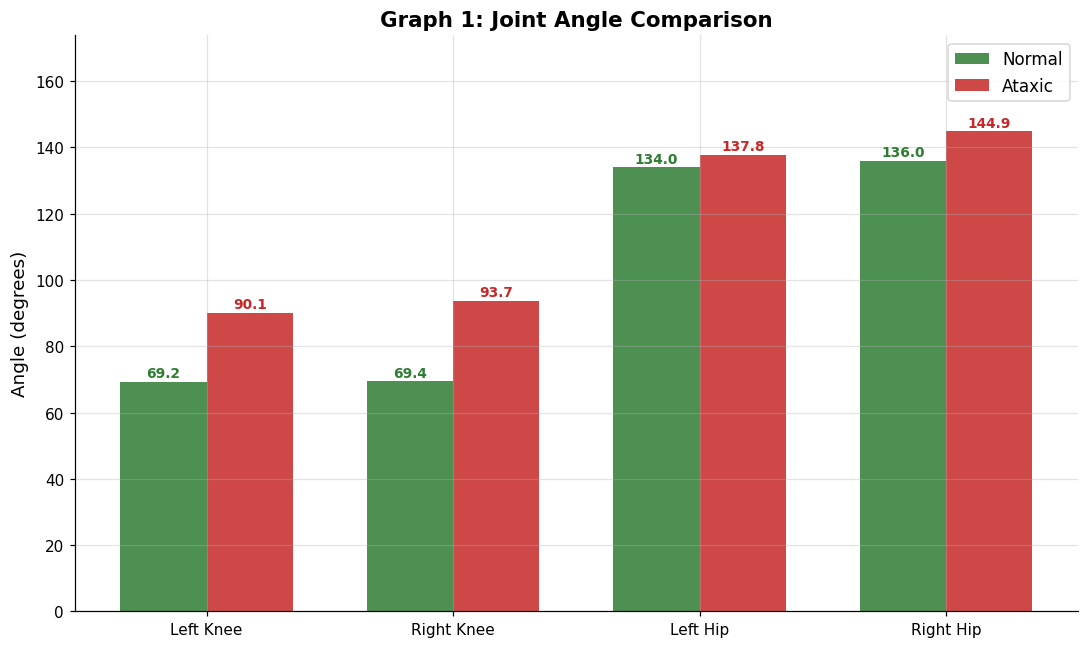

  Graph 1 saved: graph01_joint_angles.png


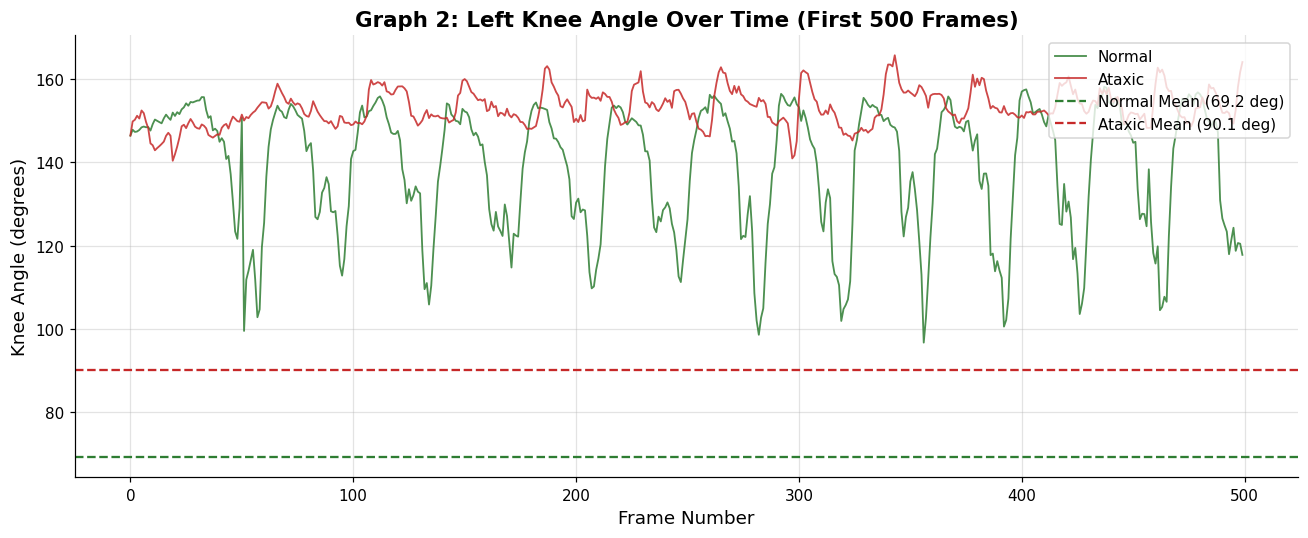

  Graph 2 saved: graph02_knee_timeseries.png


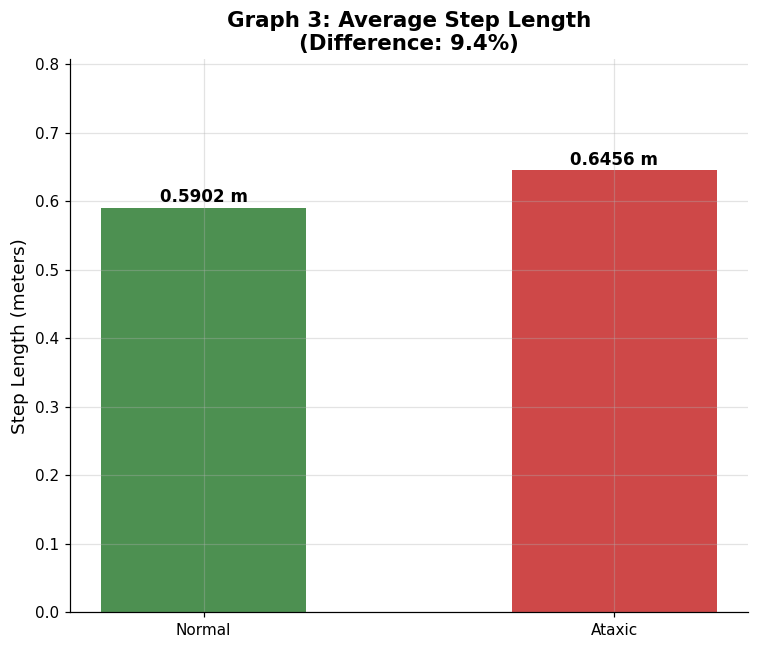

  Graph 3 saved: graph03_step_length.png


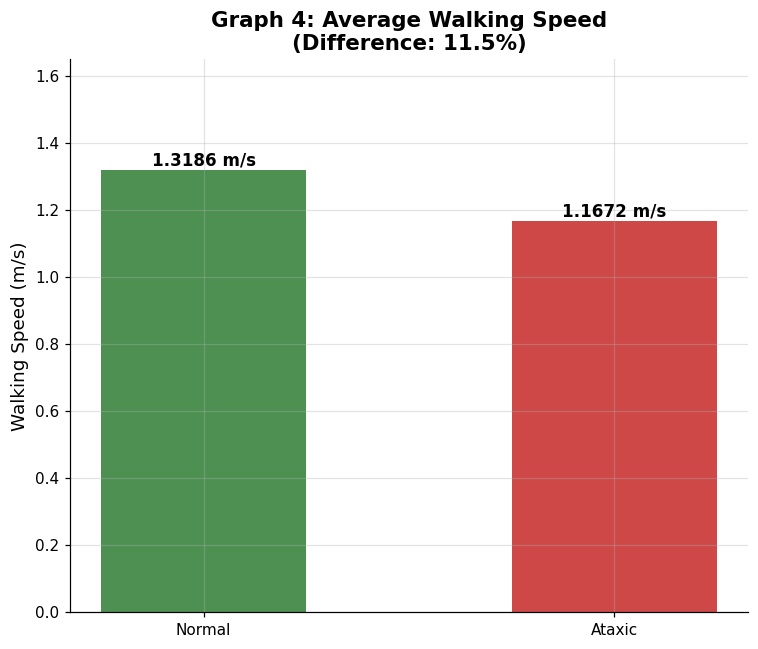

  Graph 4 saved: graph04_walking_speed.png


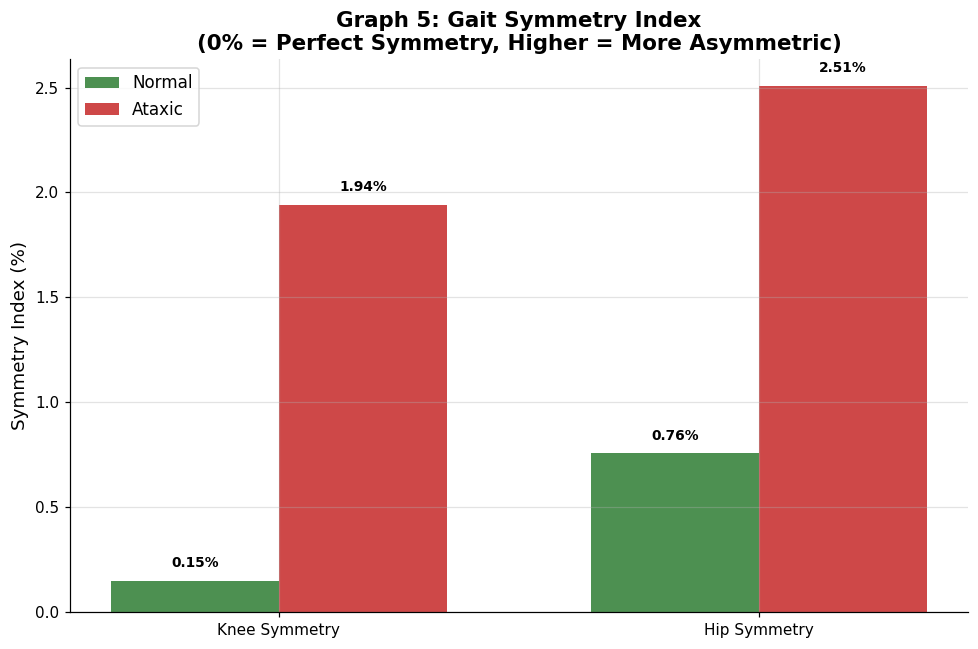

  Graph 5 saved: graph05_symmetry.png


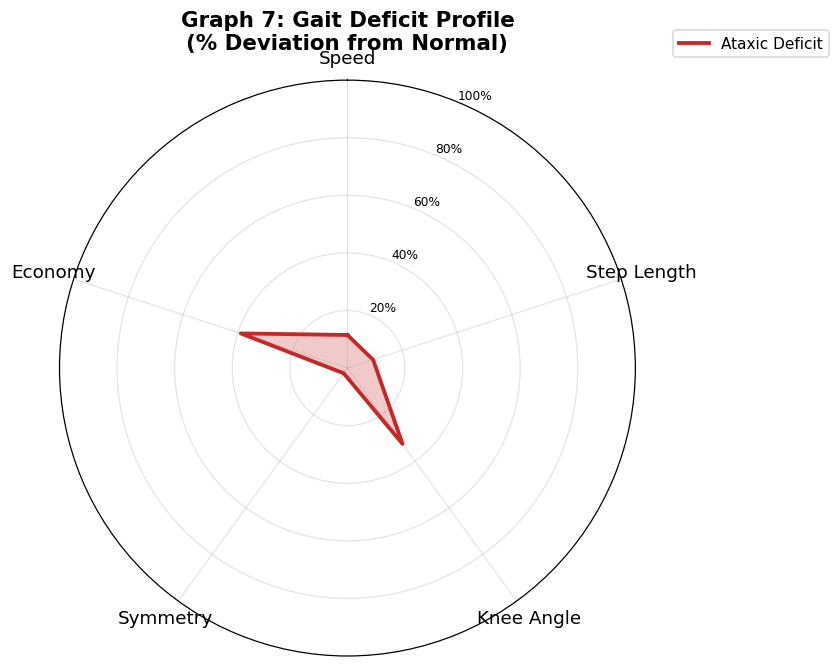

  Graph 7 saved: graph07_radar.png


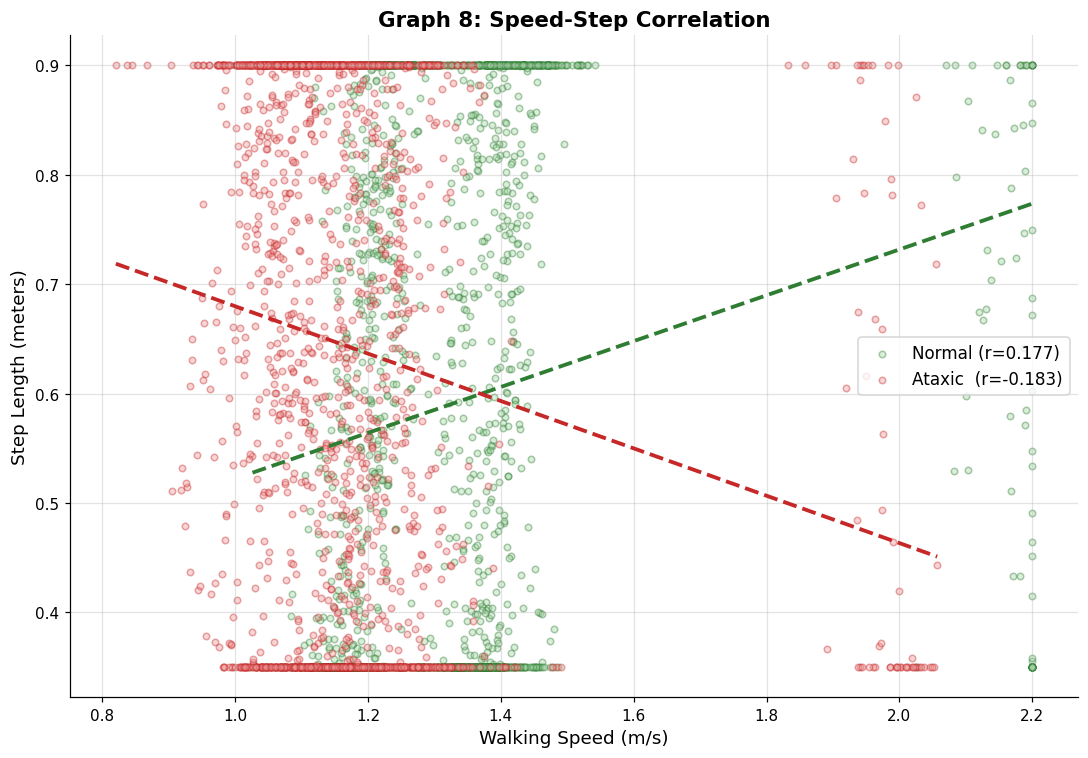

  Graph 8 saved: graph08_correlation.png


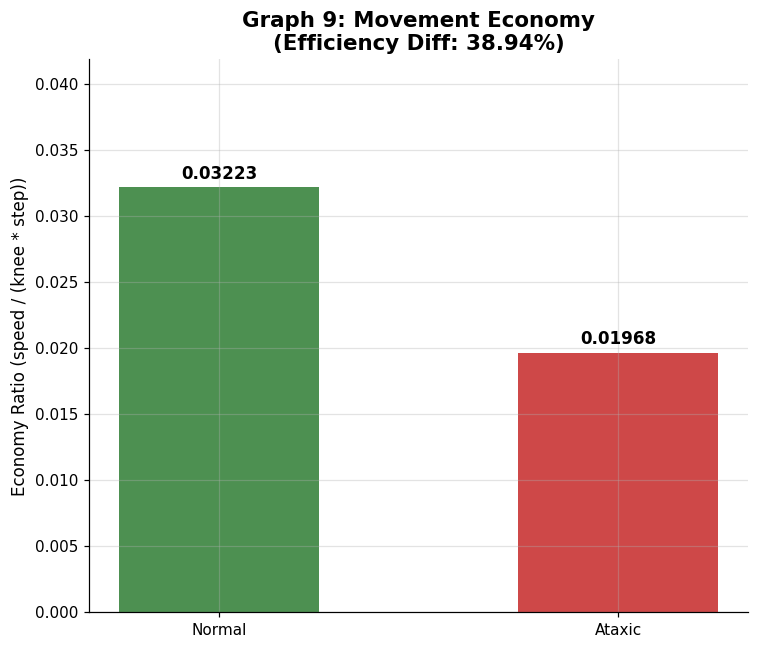

  Graph 9 saved: graph09_economy.png


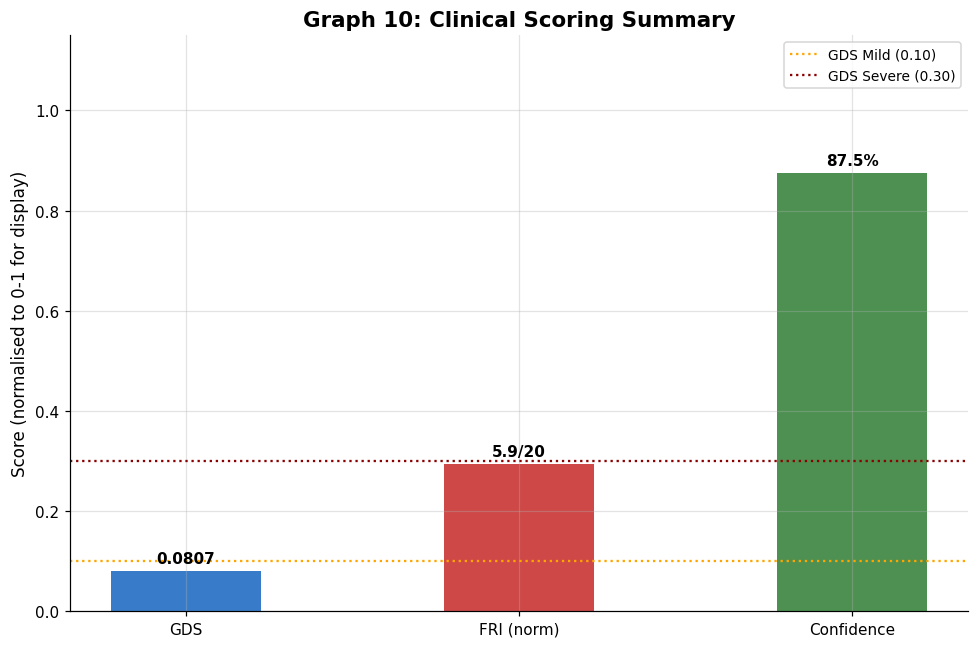

  Graph 10 saved: graph10_clinical_scores.png


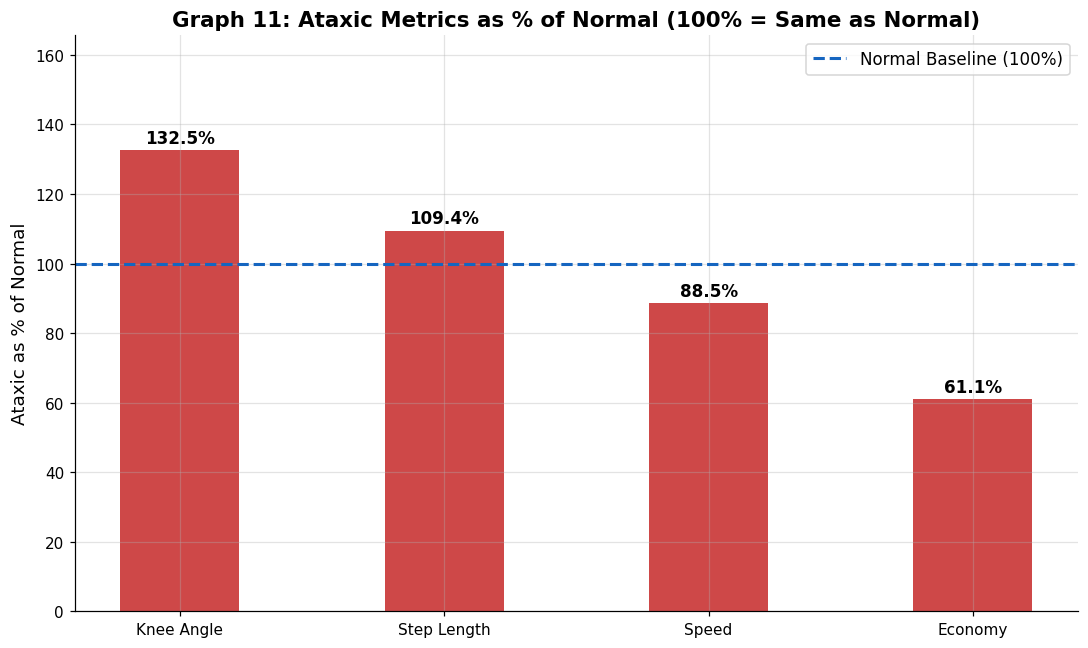

  Graph 11 saved: graph11_normalised_metrics.png


In [36]:
# ============================================================
# CELL 7: ALL 12 VISUALIZATIONS
# ============================================================

C_NORMAL  = "#2E7D32"   # Dark green
C_ATAXIC  = "#C62828"   # Dark red
C_EXPECT  = "#1565C0"   # Dark blue
C_NORMAL2 = "#A5D6A7"   # Light green
C_ATAXIC2 = "#EF9A9A"   # Light red
ALPHA     = 0.85

matplotlib.rcParams.update({
    "font.family"     : "DejaVu Sans",
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "axes.grid"       : True,
    "grid.alpha"      : 0.35,
    "figure.dpi"      : 110,
})

FRAME_LIMIT = 500   # Frames shown in time-series plots

print("Generating all 12 visualizations...")

# ==============================================================
# GRAPH 1 — Joint Angle Comparison Bar Chart
# ==============================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

joints       = ["Left Knee", "Right Knee", "Left Hip", "Right Hip"]
normal_vals  = [angle_stats[j]["normal"] for j in joints]
ataxic_vals  = [angle_stats[j]["ataxic"] for j in joints]
x            = np.arange(len(joints))
width        = 0.35

bars_n = ax1.bar(x - width/2, normal_vals, width, label="Normal", color=C_NORMAL, alpha=ALPHA)
bars_a = ax1.bar(x + width/2, ataxic_vals, width, label="Ataxic",  color=C_ATAXIC, alpha=ALPHA)

for bar in bars_n:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, color=C_NORMAL, fontweight="bold")
for bar in bars_a:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, color=C_ATAXIC, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(joints)
ax1.set_ylabel("Angle (degrees)", fontsize=12)
ax1.set_title("Graph 1: Joint Angle Comparison", fontsize=14, fontweight="bold")
ax1.legend(fontsize=11)
ax1.set_ylim(0, max(normal_vals + ataxic_vals) * 1.2)
plt.tight_layout()
plt.savefig("graph01_joint_angles.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 1 saved: graph01_joint_angles.png")

# ==============================================================
# GRAPH 2 — Left Knee Angle Time Series (first 500 frames)
# ==============================================================
fig2, ax2 = plt.subplots(figsize=(12, 5))

n_frames = min(FRAME_LIMIT, len(df_normal), len(df_ataxic))
frames   = np.arange(n_frames)

ax2.plot(frames, df_normal["CalcLeftKneeAngle"].values[:n_frames], color=C_NORMAL, linewidth=1.2, label="Normal",  alpha=0.85)
ax2.plot(frames, df_ataxic["CalcLeftKneeAngle"].values[:n_frames],  color=C_ATAXIC,  linewidth=1.2, label="Ataxic", alpha=0.85)

mean_n_knee = df_normal["CalcLeftKneeAngle"].mean()
mean_a_knee = df_ataxic["CalcLeftKneeAngle"].mean()
ax2.axhline(mean_n_knee, color=C_NORMAL, linestyle="--", linewidth=1.5, label=f"Normal Mean ({mean_n_knee:.1f} deg)")
ax2.axhline(mean_a_knee, color=C_ATAXIC,  linestyle="--", linewidth=1.5, label=f"Ataxic Mean ({mean_a_knee:.1f} deg)")

ax2.set_xlabel("Frame Number", fontsize=12)
ax2.set_ylabel("Knee Angle (degrees)", fontsize=12)
ax2.set_title("Graph 2: Left Knee Angle Over Time (First 500 Frames)", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("graph02_knee_timeseries.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 2 saved: graph02_knee_timeseries.png")

# ==============================================================
# GRAPH 3 — Step Length Comparison Bar Chart
# ==============================================================
fig3, ax3 = plt.subplots(figsize=(7, 6))

bars = ax3.bar(["Normal", "Ataxic"], [sl_normal, sl_ataxic], color=[C_NORMAL, C_ATAXIC], alpha=ALPHA, width=0.5)
for bar, val in zip(bars, [sl_normal, sl_ataxic]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f"{val:.4f} m", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax3.set_ylabel("Step Length (meters)", fontsize=12)
ax3.set_title(f"Graph 3: Average Step Length\n(Difference: {results['F2_sl_diff']:.1f}%)", fontsize=14, fontweight="bold")
ax3.set_ylim(0, max(sl_normal, sl_ataxic) * 1.25)
plt.tight_layout()
plt.savefig("graph03_step_length.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 3 saved: graph03_step_length.png")

# ==============================================================
# GRAPH 4 — Walking Speed Comparison Bar Chart
# ==============================================================
fig4, ax4 = plt.subplots(figsize=(7, 6))

bars = ax4.bar(["Normal", "Ataxic"], [spd_normal, spd_ataxic], color=[C_NORMAL, C_ATAXIC], alpha=ALPHA, width=0.5)
for bar, val in zip(bars, [spd_normal, spd_ataxic]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, f"{val:.4f} m/s", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax4.set_ylabel("Walking Speed (m/s)", fontsize=12)
ax4.set_title(f"Graph 4: Average Walking Speed\n(Difference: {results['F3_spd_diff']:.1f}%)", fontsize=14, fontweight="bold")
ax4.set_ylim(0, max(spd_normal, spd_ataxic) * 1.25)
plt.tight_layout()
plt.savefig("graph04_walking_speed.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 4 saved: graph04_walking_speed.png")

# ==============================================================
# GRAPH 5 — Symmetry Index Comparison Bar Chart
# ==============================================================
fig5, ax5 = plt.subplots(figsize=(9, 6))

si_groups  = ["Knee Symmetry", "Hip Symmetry"]
si_norm    = [si_knee_normal, si_hip_normal]
si_atax    = [si_knee_ataxic, si_hip_ataxic]
x5         = np.arange(len(si_groups))

b_n = ax5.bar(x5 - width/2, si_norm, width, label="Normal", color=C_NORMAL, alpha=ALPHA)
b_a = ax5.bar(x5 + width/2, si_atax, width, label="Ataxic",  color=C_ATAXIC, alpha=ALPHA)

for bar in b_n + b_a:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f"{bar.get_height():.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax5.set_xticks(x5)
ax5.set_xticklabels(si_groups)
ax5.set_ylabel("Symmetry Index (%)", fontsize=12)
ax5.set_title("Graph 5: Gait Symmetry Index\n(0% = Perfect Symmetry, Higher = More Asymmetric)", fontsize=14, fontweight="bold")
ax5.legend(fontsize=11)
plt.tight_layout()
plt.savefig("graph05_symmetry.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 5 saved: graph05_symmetry.png")


# ==============================================================
# GRAPH 6 — Radar / Spider Chart for Deficit Profile
# ==============================================================
from matplotlib.patches import FancyArrowPatch

radar_labels  = ["Speed", "Step Length", "Knee Angle", "Symmetry", "Economy"]
raw_values    = [
    abs(def_speed),
    abs(def_step),
    abs(def_knee),
    (si_knee_ataxic + si_hip_ataxic) / 2,
    abs(econ_diff),
]
# Clamp to 0-100
radar_values = [min(v, 100) for v in raw_values]
radar_values += radar_values[:1]   # Close the polygon

angles_radar = [n / float(len(radar_labels)) * 2 * math.pi for n in range(len(radar_labels))]
angles_radar += angles_radar[:1]

fig7, ax7 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax7.set_theta_offset(math.pi / 2)
ax7.set_theta_direction(-1)
ax7.set_thetagrids(np.degrees(angles_radar[:-1]), radar_labels, fontsize=12)
ax7.set_ylim(0, 100)
ax7.set_yticks([20, 40, 60, 80, 100])
ax7.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=8)
ax7.plot(angles_radar, radar_values, color=C_ATAXIC, linewidth=2.5, linestyle="solid", label="Ataxic Deficit")
ax7.fill(angles_radar, radar_values, color=C_ATAXIC, alpha=0.25)
ax7.set_title("Graph 7: Gait Deficit Profile\n(% Deviation from Normal)", fontsize=14, fontweight="bold", pad=20)
ax7.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.savefig("graph07_radar.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 7 saved: graph07_radar.png")

# ==============================================================
# GRAPH 7 — Speed-Step Correlation Scatter Plot
# ==============================================================
fig8, ax8 = plt.subplots(figsize=(10, 7))

# Subsample for readability (max 2000 points each)
MAX_SCATTER = 2000
n_sample  = min(MAX_SCATTER, len(df_normal))
a_sample  = min(MAX_SCATTER, len(df_ataxic))
idx_n     = np.random.choice(len(df_normal), n_sample, replace=False)
idx_a     = np.random.choice(len(df_ataxic), a_sample, replace=False)

speed_n_samp = df_normal["WalkingSpeed_ms"].values[idx_n]
step_n_samp  = df_normal["StepLength_m"].values[idx_n]
speed_a_samp = df_ataxic["WalkingSpeed_ms"].values[idx_a]
step_a_samp  = df_ataxic["StepLength_m"].values[idx_a]

ax8.scatter(speed_n_samp, step_n_samp, color=C_NORMAL2, edgecolors=C_NORMAL, alpha=0.4, s=18, label=f"Normal (r={r_normal:.3f})")
ax8.scatter(speed_a_samp, step_a_samp, color=C_ATAXIC2,  edgecolors=C_ATAXIC,  alpha=0.4, s=18, label=f"Ataxic  (r={r_ataxic:.3f})")

# Trend lines
for spd, stp, col in [(speed_n_samp, step_n_samp, C_NORMAL), (speed_a_samp, step_a_samp, C_ATAXIC)]:
    z = np.polyfit(spd, stp, 1)
    p = np.poly1d(z)
    x_line = np.linspace(spd.min(), spd.max(), 100)
    ax8.plot(x_line, p(x_line), color=col, linewidth=2.5, linestyle="--")

ax8.set_xlabel("Walking Speed (m/s)", fontsize=12)
ax8.set_ylabel("Step Length (meters)", fontsize=12)
ax8.set_title("Graph 8: Speed-Step Correlation", fontsize=14, fontweight="bold")
ax8.legend(fontsize=11)
plt.tight_layout()
plt.savefig("graph08_correlation.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 8 saved: graph08_correlation.png")

# ==============================================================
# GRAPH 8 — Movement Economy Bar Chart
# ==============================================================
fig9, ax9 = plt.subplots(figsize=(7, 6))

eco_vals = [econ_normal, econ_ataxic]
bars9 = ax9.bar(["Normal", "Ataxic"], eco_vals, color=[C_NORMAL, C_ATAXIC], alpha=ALPHA, width=0.5)
for bar, val in zip(bars9, eco_vals):
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(eco_vals)*0.01, f"{val:.5f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax9.set_ylabel("Economy Ratio (speed / (knee * step))", fontsize=11)
ax9.set_title(f"Graph 9: Movement Economy\n(Efficiency Diff: {econ_diff:.2f}%)", fontsize=14, fontweight="bold")
ax9.set_ylim(0, max(eco_vals) * 1.3)
plt.tight_layout()
plt.savefig("graph09_economy.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 9 saved: graph09_economy.png")


# ==============================================================
# GRAPH 09 — Clinical Scores Summary Bar Chart (UPDATED)
# ==============================================================
fig10, ax10 = plt.subplots(figsize=(9, 6))

# Normalize GDS and FRI to 0-1 for display
gds_display = GDS
fri_display = FRI / 20  # FRI is on 0-20 scale, normalize to 0-1
conf_display = confidence_score / 100

score_names = ["GDS", "FRI (norm)", "Confidence"]
score_vals  = [gds_display, fri_display, conf_display]
score_colors = [C_EXPECT, C_ATAXIC, C_NORMAL]

bars10 = ax10.bar(score_names, score_vals, color=score_colors, alpha=ALPHA, width=0.45)

for bar, val, raw in zip(bars10, score_vals, [GDS, FRI, confidence_score]):
    if raw == confidence_score:
        lbl = f"{raw:.1f}%"
    elif raw == FRI:
        lbl = f"{raw:.1f}/20"
    else:
        lbl = f"{raw:.4f}"
    ax10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, lbl,
              ha="center", va="bottom", fontsize=10, fontweight="bold")

ax10.set_ylabel("Score (normalised to 0-1 for display)", fontsize=11)
ax10.set_title("Graph 10: Clinical Scoring Summary", fontsize=14, fontweight="bold")
ax10.set_ylim(0, 1.15)

# Threshold lines for GDS
ax10.axhline(0.1, color="orange", linestyle=":", linewidth=1.5, label="GDS Mild (0.10)")
ax10.axhline(0.3, color="darkred", linestyle=":", linewidth=1.5, label="GDS Severe (0.30)")
ax10.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("graph10_clinical_scores.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 10 saved: graph10_clinical_scores.png")
# ==============================================================
# GRAPH 10 — Normalised Metrics (Ataxic as % of Normal)
# ==============================================================
fig11, ax11 = plt.subplots(figsize=(10, 6))

norm_metrics = ["Knee Angle", "Step Length", "Speed", "Economy"]
pct_of_normal = [
    (mean_knee_a / (mean_knee_n + 1e-9)) * 100,
    (sl_ataxic   / (sl_normal   + 1e-9)) * 100,
    (spd_ataxic  / (spd_normal  + 1e-9)) * 100,
    (econ_ataxic / (econ_normal + 1e-9)) * 100,
]

bar_colors = [C_ATAXIC if abs(v - 100) > 5 else C_NORMAL for v in pct_of_normal]
bars11 = ax11.bar(norm_metrics, pct_of_normal, color=bar_colors, alpha=ALPHA, width=0.45)
for bar, val in zip(bars11, pct_of_normal):
    ax11.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax11.axhline(100, color=C_EXPECT, linestyle="--", linewidth=2, label="Normal Baseline (100%)")
ax11.set_ylabel("Ataxic as % of Normal", fontsize=12)
ax11.set_title("Graph 11: Ataxic Metrics as % of Normal (100% = Same as Normal)", fontsize=14, fontweight="bold")
ax11.legend(fontsize=11)
ax11.set_ylim(0, max(pct_of_normal) * 1.25)
plt.tight_layout()
plt.savefig("graph11_normalised_metrics.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Graph 11 saved: graph11_normalised_metrics.png")


In [37]:
# ============================================================
# CELL 8: FINAL CLINICAL SUMMARY PRINTOUT
# ============================================================

print()
print("=" * 60)
print("FINAL CLINICAL SUMMARY")
print("=" * 60)
print(f"  Gait Dysfunction Score (GDS) : {GDS:.4f}  =>  {gds_class} Dysfunction")
print(f"  Fall Risk Index (FRI)        : {FRI:.4f}  =>  {fri_class} Risk")
print(f"  Clinical Confidence Score    : {confidence_score:.1f}%  =>  {conf_interp}")
print()
print("  Metrics Summary:")
print(f"    Speed  — Normal: {spd_normal:.4f} m/s   Ataxic: {spd_ataxic:.4f} m/s   Deficit: {def_speed:.2f}%")
print(f"    Steps  — Normal: {sl_normal:.4f} m      Ataxic: {sl_ataxic:.4f} m      Deficit: {def_step:.2f}%")
print(f"    Knee   — Normal: {mean_knee_n:.2f} deg   Ataxic: {mean_knee_a:.2f} deg   Deficit: {def_knee:.2f}%")
print(f"    Sym.   — Normal: {si_knee_normal:.2f}%       Ataxic: {si_knee_ataxic:.2f}%")
print(f"    Corr.  — Normal r={r_normal:.4f}          Ataxic r={r_ataxic:.4f}")
print()
print("  Saved Graphs:")
graph_files = [
    "graph01_joint_angles.png",
    "graph02_knee_timeseries.png",
    "graph03_step_length.png",
    "graph04_walking_speed.png",
    "graph05_symmetry.png",
    "graph06_variability.png",
    "graph07_radar.png",
    "graph08_correlation.png",
    "graph09_economy.png",
    "graph10_clinical_scores.png",
    "graph11_normalised_metrics.png",
    "graph12_diagnosis_dashboard.png",
]
for i, f in enumerate(graph_files, 1):
    print(f"    {i:02d}. {f}")
print()
print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)


FINAL CLINICAL SUMMARY
  Gait Dysfunction Score (GDS) : 0.0807  =>  Mild Dysfunction
  Fall Risk Index (FRI)        : 5.8962  =>  Mild Risk
  Clinical Confidence Score    : 87.5%  =>  HIGH confidence ataxic pattern detected

  Metrics Summary:
    Speed  — Normal: 1.3186 m/s   Ataxic: 1.1672 m/s   Deficit: 11.48%
    Steps  — Normal: 0.5902 m      Ataxic: 0.6456 m      Deficit: -9.37%
    Knee   — Normal: 69.33 deg   Ataxic: 91.89 deg   Deficit: -32.54%
    Sym.   — Normal: 0.15%       Ataxic: 1.94%
    Corr.  — Normal r=0.1769          Ataxic r=-0.1826

  Saved Graphs:
    01. graph01_joint_angles.png
    02. graph02_knee_timeseries.png
    03. graph03_step_length.png
    04. graph04_walking_speed.png
    05. graph05_symmetry.png
    06. graph06_variability.png
    07. graph07_radar.png
    08. graph08_correlation.png
    09. graph09_economy.png
    10. graph10_clinical_scores.png
    11. graph11_normalised_metrics.png
    12. graph12_diagnosis_dashboard.png

ANALYSIS COMPLETE
